In [1]:
from pathlib import Path
from datetime import datetime, timedelta
from textwrap import fill

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.artist import Artist
from matplotlib.axes import Axes
from matplotlib.legend import Legend
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.lines import Line2D
from matplotlib.text import Text
from matplotlib.ticker import NullLocator
from matplotlib.transforms import Affine2D, ScaledTranslation, Transform

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"],
    "pdf.fonttype": 42,
})

In [2]:
# All sizes are in points, at the final figure size
SAMPLE_SIZE = 15
INTERNAL_SIZE = 9
RECOMBINANT_SIZE = 15
EDGE_WIDTH = 1.1
LABEL_FONTSIZE = 7
LEFT_PARENT_COLOR = "#88DD88"
RIGHT_PARENT_COLOR = "#6AAEE0"
BREAKPOINT_COLOR = "#A0A0A0"
GENOME_LENGTH = 29903
SPIKE = (21563, 25384)

node_radius = {
    "sample": SAMPLE_SIZE / 2,
    "internal": INTERNAL_SIZE / 2,
    "recombinant": RECOMBINANT_SIZE / 2,
}


def _points_transform(ax: Axes, x: float, y: float) -> Transform:
    # Coordinates in points, relative to the data point (x, y)
    return (
        Affine2D().scale(1 / 72)
        + ax.figure.dpi_scale_trans
        + ScaledTranslation(x, y, ax.transData)
    )


def _direction(ax: Axes, start: pd.Series, end: pd.Series) -> np.ndarray:
    d = ax.transData.transform((end["x"], end["y"])) - ax.transData.transform((start["x"], start["y"]))
    return d / np.hypot(*d)


def _time_scale(nodes_df: pd.DataFrame, time_weight: float):
    # Piecewise-linear map from time to axis position, blending linear time with the
    # rank of distinct node times (time_weight=1 is linear, 0 spaces node times evenly)
    times = nodes_df.loc[nodes_df["type"].isin(list(node_radius)), "y"]
    knots = np.unique(np.round(times * 2) / 2)
    rank = np.arange(len(knots)) / (len(knots) - 1)
    warped = time_weight * (knots - knots[0]) / (knots[-1] - knots[0]) + (1 - time_weight) * rank
    # Extrapolate linearly beyond the knots so that margins and anchors still map sensibly
    slope = 1 / (knots[-1] - knots[0])

    def forward(y):
        y = np.asarray(y, dtype=float)
        w = np.interp(y, knots, warped)
        w = np.where(y < knots[0], (y - knots[0]) * slope, w)
        return np.where(y > knots[-1], 1 + (y - knots[-1]) * slope, w)

    def inverse(w):
        w = np.asarray(w, dtype=float)
        y = np.interp(w, warped, knots)
        y = np.where(w < 0, knots[0] + w / slope, y)
        return np.where(w > 1, knots[-1] + (w - 1) / slope, y)

    return forward, inverse


def _footprint(node: pd.Series, has_clade: bool) -> tuple[float, float, float, float]:
    # Approximate (left, right, bottom, top) extent of a node, its outside label
    # and its collapsed clade, in points relative to the node centre
    r = node_radius[node["type"]]
    left, right, bottom, top = -r, r, -r, r
    if pd.notna(node["label_outside"]):
        width = 0.55 * LABEL_FONTSIZE * len(node["label_outside"])
        side = node["outside_pos"]
        if side == "right":
            right += width + 2
        elif side == "left":
            left -= width + 2
        elif side == "top":
            top += LABEL_FONTSIZE + 2
            left, right = min(left, -width / 2), max(right, width / 2)
        else:
            bottom -= 2 * LABEL_FONTSIZE + 2
            left, right = min(left, -width / 4), max(right, width / 4)
    if has_clade:
        bottom = min(bottom, -(r + 20))
    return left, right, bottom, top


def _drop_children(ax: Axes, nodes_df: pd.DataFrame, edges_df: pd.DataFrame, min_drop: float) -> pd.DataFrame:
    # Artistic licence with node times: move each node at least min_drop points below its
    # parent, so that edges between nodes with (nearly) the same time are visible
    nodes_df = nodes_df.copy()
    to_points = 72 / ax.figure.dpi
    screen_y = {
        u: ax.transData.transform((0, y))[1] * to_points
        for u, y in nodes_df["y"].items()
    }
    tree_edges = [
        (edge["parent"], edge["child"])
        for _, edge in edges_df.iterrows()
        if nodes_df.loc[edge["parent"], "type"] in node_radius
        and nodes_df.loc[edge["child"], "type"] in node_radius
    ]
    changed = True
    while changed:
        changed = False
        for parent, child in tree_edges:
            if screen_y[child] > screen_y[parent] - min_drop + 1e-6:
                screen_y[child] = screen_y[parent] - min_drop
                changed = True
    inverted = ax.transData.inverted()
    for u in nodes_df.index[nodes_df["type"].isin(list(node_radius))]:
        nodes_df.loc[u, "y"] = inverted.transform((0, screen_y[u] / to_points))[1]
    for u in nodes_df.index[nodes_df["type"] == "clade"]:
        nodes_df.loc[u, "y"] = nodes_df.loc[-u, "y"]
    for _, edge in edges_df[edges_df["parent"].map(nodes_df["type"]) == "anchor"].iterrows():
        nodes_df.loc[edge["parent"], "y"] = nodes_df.loc[edge["child"], "y"] + 20
    return nodes_df


def _set_limits(ax: Axes, nodes_df: pd.DataFrame, forward) -> None:
    # Anchors only set the direction of truncated edges, so don't count them in the limits
    shown = nodes_df[nodes_df["type"] != "anchor"]
    xspan = shown["x"].max() - shown["x"].min()
    ylo, yhi = forward(shown["y"].min()), forward(shown["y"].max())
    ypad = 0.08 * (yhi - ylo)
    ax.set(
        xlim=(shown["x"].min() - 0.03 * xspan, shown["x"].max() + 0.05 * xspan),
        ylim=(float(ax.yaxis.get_transform().inverted().transform(ylo - ypad)),
              float(ax.yaxis.get_transform().inverted().transform(yhi + ypad))),
    )


def _spread_x(ax: Axes, nodes_df: pd.DataFrame, edges_df: pd.DataFrame, pad: float = 3) -> pd.DataFrame:
    # Push nodes apart horizontally, keeping their left-to-right order, so that nodes whose
    # footprints overlap vertically don't collide. The original spacing is shrunk as little
    # as possible to fit the result within the axes. Returns x in points.
    nodes_df = nodes_df.copy()
    shown = nodes_df[nodes_df["type"].isin(list(node_radius))].sort_values("x")
    to_points = 72 / ax.figure.dpi
    width = ax.get_window_extent().width * to_points
    y = ax.transData.transform(np.column_stack([np.zeros(len(shown)), shown["y"]]))[:, 1] * to_points
    extents = np.array([_footprint(node, -u in nodes_df.index) for u, node in shown.iterrows()])
    extents[:, 2:] += y[:, None]
    x_span = shown["x"].max() - shown["x"].min()
    x0 = (shown["x"].to_numpy() - shown["x"].min()) / x_span * width

    def sweep(k):
        x = k * x0
        for i in range(len(x)):
            overlap = (extents[:i, 2] < extents[i, 3] + pad) & (extents[i, 2] < extents[:i, 3] + pad)
            if overlap.any():
                x[i] = max(x[i], np.max(x[:i][overlap] + extents[:i, 1][overlap]) - extents[i, 0] + pad)
        return x

    def total_width(x):
        return np.max(x + extents[:, 1]) - np.min(x + extents[:, 0])

    lo, hi = 0.0, 1.0
    for _ in range(30):
        k = (lo + hi) / 2
        if total_width(sweep(k)) <= width:
            lo = k
        else:
            hi = k
    x = sweep(lo)
    new_x = dict(zip(shown.index, x))
    # Clades hang below their parent; anchors keep their offset from their child,
    # which only sets the direction of the truncated edge
    for u in nodes_df.index[nodes_df["type"] == "clade"]:
        new_x[u] = new_x[-u]
    for _, edge in edges_df[edges_df["parent"].map(nodes_df["type"]) == "anchor"].iterrows():
        offset = nodes_df.loc[edge["parent"], "x"] - nodes_df.loc[edge["child"], "x"]
        new_x[edge["parent"]] = new_x[edge["child"]] + offset / x_span * width * max(lo, 0.5)
    nodes_df["x"] = nodes_df.index.map(new_x)
    left = np.min(x + extents[:, 0]) - pad
    ax.set_xlim(left, left + width)
    return nodes_df


def _draw_nodes(ax: Axes, nodes_df: pd.DataFrame) -> None:
    for _, node in nodes_df.iterrows():
        if node["type"] not in node_radius:
            continue
        r = node_radius[node["type"]]
        ax.plot(
            node["x"],
            node["y"],
            marker="s" if node["type"] == "sample" else "o",
            markersize=2 * r,
            markerfacecolor=node["color"],
            markeredgecolor="none" if node["type"] == "internal" else "black",
            markeredgewidth=0.8,
            zorder=3,
        )
        label_inside = "R" if node["type"] == "recombinant" else node["label_inside"]
        if pd.notna(label_inside):
            ax.text(
                node["x"],
                node["y"],
                label_inside,
                ha="center",
                va="center",
                fontsize={1: 9, 2: 7.5, 3: 6}.get(len(label_inside), 5.5),
                fontweight="bold" if node["type"] == "recombinant" else "normal",
                color="white" if node["color"] == "black" else "black",
                zorder=4,
            )
        if pd.notna(node["label_outside"]):
            d = r + 2
            dx, dy, ha, va = {
                "top": (0, d, "center", "bottom"),
                "bottom": (0, -d, "center", "top"),
                "left": (-d, 0, "right", "center"),
                "right": (d, 0, "left", "center"),
            }[node["outside_pos"]]
            ax.annotate(
                fill(node["label_outside"], width=16),
                (node["x"], node["y"]),
                xytext=(dx, dy),
                textcoords="offset points",
                ha=ha,
                va=va,
                multialignment="center",
                fontsize=LABEL_FONTSIZE,
                zorder=4,
            )


def _draw_clades(ax: Axes, nodes_df: pd.DataFrame) -> None:
    # Collapsed clades hang a fixed distance below their parent node
    for _, clade in nodes_df[nodes_df["type"] == "clade"].iterrows():
        parent = nodes_df.loc[-clade["id"]]
        trans = _points_transform(ax, parent["x"], parent["y"])
        top = -node_radius[parent["type"]]
        ax.plot([0, 0], [top, top - 9], linestyle=":", color="black", linewidth=0.9, transform=trans, zorder=2)
        boxed = clade["color"] not in ("white", "grey")
        ax.text(
            0,
            top - 10,
            f"{int(clade['label_inside']):,}",
            ha="center",
            va="top",
            fontsize=LABEL_FONTSIZE,
            transform=trans,
            bbox=dict(boxstyle="square,pad=0.2", facecolor=clade["color"], edgecolor="none") if boxed else None,
            zorder=4,
        )


def _draw_edges(
    ax: Axes,
    nodes_df: pd.DataFrame,
    edges_df: pd.DataFrame,
    parent_colors: dict[tuple[int, int], str],
) -> None:
    for _, edge in edges_df.iterrows():
        parent = nodes_df.loc[edge["parent"]]
        child = nodes_df.loc[edge["child"]]
        if child["type"] == "clade":
            continue
        if parent["type"] == "anchor":
            # Truncated lineage leading to an ancestor outside the subgraph
            u = _direction(ax, child, parent)
            trans = _points_transform(ax, child["x"], child["y"])
            ax.plot([0, 14 * u[0]], [0, 14 * u[1]], color="black", linewidth=EDGE_WIDTH, transform=trans, zorder=1)
            ax.plot([14 * u[0], 26 * u[0]], [14 * u[1], 26 * u[1]], linestyle=":", color="black", linewidth=EDGE_WIDTH, transform=trans, zorder=1)
            continue
        color = parent_colors.get((edge["parent"], edge["child"]), edge["color"])
        if parent["clipped"]:
            # The parent is older than the axis range: dot the end of the edge to show a time break
            length = np.hypot(*(ax.transData.transform((child["x"], child["y"])) - ax.transData.transform((parent["x"], parent["y"])))) * 72 / ax.figure.dpi
            u = _direction(ax, parent, child)
            gap = min(12, length / 3)
            trans = _points_transform(ax, parent["x"], parent["y"])
            ax.plot([0, gap * u[0]], [0, gap * u[1]], linestyle=":", color=color, linewidth=EDGE_WIDTH * 1.5, transform=trans, zorder=1)
            ax.plot([gap * u[0], length * u[0]], [gap * u[1], length * u[1]], color=color, linewidth=EDGE_WIDTH * 1.5, transform=trans, zorder=1)
        else:
            ax.plot(
                [parent["x"], child["x"]],
                [parent["y"], child["y"]],
                color=color,
                linewidth=EDGE_WIDTH * (1.5 if color != "black" else 1),
                zorder=1,
            )
        n = edge["num_mutations"]
        if n:
            u = _direction(ax, parent, child)
            p = np.array([-u[1], u[0]]) * 3
            # Midpoint on screen, since the time axis may be non-linear
            mid = ax.transData.inverted().transform(
                (ax.transData.transform((parent["x"], parent["y"])) + ax.transData.transform((child["x"], child["y"]))) / 2
            )
            trans = _points_transform(ax, *mid)
            for i in range(n):
                c = (i - (n - 1) / 2) * 2.4 * u
                ax.plot(
                    [c[0] - p[0], c[0] + p[0]],
                    [c[1] - p[1], c[1] + p[1]],
                    color="black",
                    linewidth=1.2,
                    solid_capstyle="butt",
                    transform=trans,
                    zorder=2,
                )


def _draw_genome_bar(ax: Axes, bounds: list[float], left: int, right: int) -> None:
    inset = ax.inset_axes(bounds)
    for start, end, color in [
        (0, left, LEFT_PARENT_COLOR),
        (left, right, BREAKPOINT_COLOR),
        (right, GENOME_LENGTH, RIGHT_PARENT_COLOR),
    ]:
        inset.barh(0.5, end - start, left=start, height=1, color=color, linewidth=0)
    inset.plot(SPIKE, [1.5, 1.5], color="black", linewidth=1.5, solid_capstyle="butt")
    inset.text(sum(SPIKE) / 2, 1.8, "Spike", ha="center", va="bottom", fontsize=LABEL_FONTSIZE)
    inset.text(0, 0.5, "5' ", ha="right", va="center", fontsize=LABEL_FONTSIZE)
    inset.text(GENOME_LENGTH, 0.5, " 3'", ha="left", va="center", fontsize=LABEL_FONTSIZE)
    inset.set(xlim=(0, GENOME_LENGTH), ylim=(0, 3))
    inset.axis("off")


class RecombinantLegendHandler(HandlerLine2D):
    def create_artists(
        self,
        legend: Legend,
        orig_handle: Line2D,
        xdescent: float,
        ydescent: float,
        width: float,
        height: float,
        fontsize: float,
        trans: Transform,
    ) -> list[Artist]:
        artists = list(super().create_artists(legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans))
        artists.append(Text(
            x=width / 2 - xdescent,
            y=height / 2 - ydescent,
            text="R",
            color="white",
            fontsize=0.65 * orig_handle.get_markersize(),
            fontweight="bold",
            ha="center",
            va="center",
            transform=trans,
        ))
        return artists


class VerticalLineLegendHandler(HandlerLine2D):
    def create_artists(
        self,
        legend: Legend,
        orig_handle: Line2D,
        xdescent: float,
        ydescent: float,
        width: float,
        height: float,
        fontsize: float,
        trans: Transform,
    ) -> list[Artist]:
        x = width / 2 - xdescent
        line = Line2D([x, x], [-ydescent - 0.4 * height, height * 1.4 - ydescent], transform=trans)
        line.update_from(orig_handle)
        return [line]


def _add_legend(ax: Axes, kind: str) -> None:
    def patch(color, label):
        return Line2D([], [], color=color, linewidth=5, solid_capstyle="butt", label=label)

    def node(marker, size, facecolor, edgecolor, label):
        return Line2D(
            [], [], marker=marker, linestyle="none", markersize=size,
            markerfacecolor=facecolor, markeredgecolor=edgecolor, markeredgewidth=0.8, label=label,
        )

    handler_map = {}
    if kind == "genome":
        handles = [
            patch(LEFT_PARENT_COLOR, "Left parent"),
            patch(RIGHT_PARENT_COLOR, "Right parent"),
            patch(BREAKPOINT_COLOR, "Breakpoint interval"),
            Line2D([], [], marker="|", linestyle="none", markersize=7, markeredgewidth=1.2, color="black", label="Mutation"),
        ]
    else:
        recombinant = node("o", RECOMBINANT_SIZE * 0.8, "black", "black", "Recombination node")
        clade = Line2D([], [], linestyle=":", color="black", linewidth=0.9, label="Collapsed clade")
        handles = [
            recombinant,
            node("s", SAMPLE_SIZE * 0.8, "white", "black", "Sample node"),
            node("o", INTERNAL_SIZE, "grey", "none", "Non-sample node"),
            clade,
        ]
        handler_map = {recombinant: RecombinantLegendHandler(), clade: VerticalLineLegendHandler()}
    ax.legend(
        handles=handles,
        loc="upper left",
        bbox_to_anchor=(0.05, -0.02),
        ncol=2,
        frameon=False,
        fontsize=9,
        handlelength=1.5,
        columnspacing=2.5,
        handler_map=handler_map,
    )


def _format_axes(ax: Axes, nodes_df: pd.DataFrame, reference_date: datetime, letter: str, title: str) -> None:
    unclipped = nodes_df[~nodes_df["clipped"] & (nodes_df["type"] != "anchor")]
    ymin, ymax = unclipped["y"].min(), unclipped["y"].max()
    months = pd.date_range(reference_date - timedelta(days=ymax), reference_date - timedelta(days=ymin), freq="MS")
    # Drop month ticks squeezed together by the time scale
    ticks = []
    for m in months:
        y = (reference_date - m).days
        screen = ax.transData.transform((0, y))[1] * 72 / ax.figure.dpi
        if len(ticks) == 0 or abs(screen - ticks[-1][0]) >= 10:
            ticks.append((screen, y, m.strftime("%Y-%m")))
    ax.set_yticks([y for _, y, _ in ticks], [label for _, _, label in ticks])
    ax.yaxis.set_minor_locator(NullLocator())
    ax.tick_params(axis="y", length=0, labelsize=9)
    for _, y, _ in ticks:
        ax.axhline(y, color="#E8E8E8", linewidth=0.6, zorder=0)
    ax.xaxis.set_visible(False)
    for spine in ("top", "right", "bottom"):
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["left"].set_bounds(ymin, ymax)
    for text, x, size in [(letter, -48, 18), (title, -30, 12)]:
        ax.annotate(
            text, (0, 1), xycoords="axes fraction", xytext=(x, 14), textcoords="offset points",
            fontsize=size, ha="left", va="baseline",
        )


def create_subgraph(
    nodes_df: pd.DataFrame,
    edges_df: pd.DataFrame,
    reference_date: datetime,
    ax: Axes,
    letter: str,
    title: str,
    recombinants: pd.DataFrame,
    genome_bar_bounds: list[float] | None = None,
    legend: str | None = None,
    time_weight: float = 1.0,
    spread: bool = False,
    min_drop: float = 0,
) -> Axes:
    forward, inverse = _time_scale(nodes_df, time_weight)
    ax.set_yscale("function", functions=(forward, inverse))
    _set_limits(ax, nodes_df, forward)
    if min_drop > 0:
        nodes_df = _drop_children(ax, nodes_df, edges_df, min_drop)
        _set_limits(ax, nodes_df, forward)
    if spread:
        nodes_df = _spread_x(ax, nodes_df, edges_df)
    parent_colors = {}
    for u in nodes_df.index[nodes_df["type"] == "recombinant"]:
        rec = recombinants.loc[u]
        parent_colors[(rec["parent_left"], u)] = LEFT_PARENT_COLOR
        parent_colors[(rec["parent_right"], u)] = RIGHT_PARENT_COLOR
        if genome_bar_bounds is not None:
            _draw_genome_bar(ax, genome_bar_bounds, rec["interval_left"], rec["interval_right"])

    _draw_edges(ax, nodes_df, edges_df, parent_colors)
    _draw_nodes(ax, nodes_df)
    _draw_clades(ax, nodes_df)
    if legend is not None:
        _add_legend(ax, legend)
    _format_axes(ax, nodes_df, reference_date, letter, title)
    return ax

In [3]:
data_dir = Path(".")
node_col_types = {
    "id": int,
    "type": str,
    "color": str,
    "label_inside": str,
    "label_outside": str,
    "x": float,
    "y": float,
}
edge_col_types = {
    "id": int,
    "parent": int,
    "child": int,
    "style": str,
    "color": str,
    "num_mutations": int,
}

In [4]:
def get_layout_data(
    nodes_file: str | Path,
    edges_file: str | Path,
    max_y: float | None = None,
    extra_labels: dict[int, tuple[str, str]] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    nodes_df = pd.read_csv(
        nodes_file,
        dtype=node_col_types,
        keep_default_na=False,
        na_values=["NA"],
    ).set_index("id", drop=False)
    # Pull ancestors older than max_y down to max_y, so the panel isn't dominated
    # by long branches to the recombinant's parents
    nodes_df["clipped"] = False
    if max_y is not None:
        clip = (nodes_df["y"] > max_y) & (nodes_df["type"] != "anchor")
        nodes_df.loc[clip, ["y", "clipped"]] = [max_y, True]
    nodes_df["x"] = nodes_df["x"] * 100 + 80
    for u, (label, pos) in (extra_labels or {}).items():
        nodes_df.loc[u, ["label_outside", "outside_pos"]] = [label, pos]

    edges_df = pd.read_csv(
        edges_file,
        dtype=edge_col_types,
    )
    # Anchors share their child's time: move them to the (possibly clipped) child
    for _, edge in edges_df[edges_df["parent"].map(nodes_df["type"]) == "anchor"].iterrows():
        nodes_df.loc[edge["parent"], "y"] = nodes_df.loc[edge["child"], "y"] + 20

    return (nodes_df, edges_df)

In [5]:
recombinants = pd.read_csv("../data/recombinants.csv").set_index("recombinant")

xa_nodes_df, xa_edges_df = get_layout_data(
    data_dir / "XA_nodes.csv",
    data_dir / "XA_edges.csv",
    extra_labels={
        108722: ("B.1.1.7 (Alpha)", "right"),
        # Jackson et al. "Group A" samples ERR5308556 and ERR5414941
        132995: ("Jackson et al. sample", "bottom"),
        164802: ("Jackson et al. sample", "bottom"),
    },
)
xn_nodes_df, xn_edges_df = get_layout_data(
    data_dir / "XN-XAU_nodes.csv",
    data_dir / "XN-XAU_edges.csv",
)
xq_nodes_df, xq_edges_df = get_layout_data(
    data_dir / "XAA-XAB-XAG-XAM-XQ-XR-XU_nodes.csv",
    data_dir / "XAA-XAB-XAG-XAM-XQ-XR-XU_edges.csv",
    max_y=885,
)

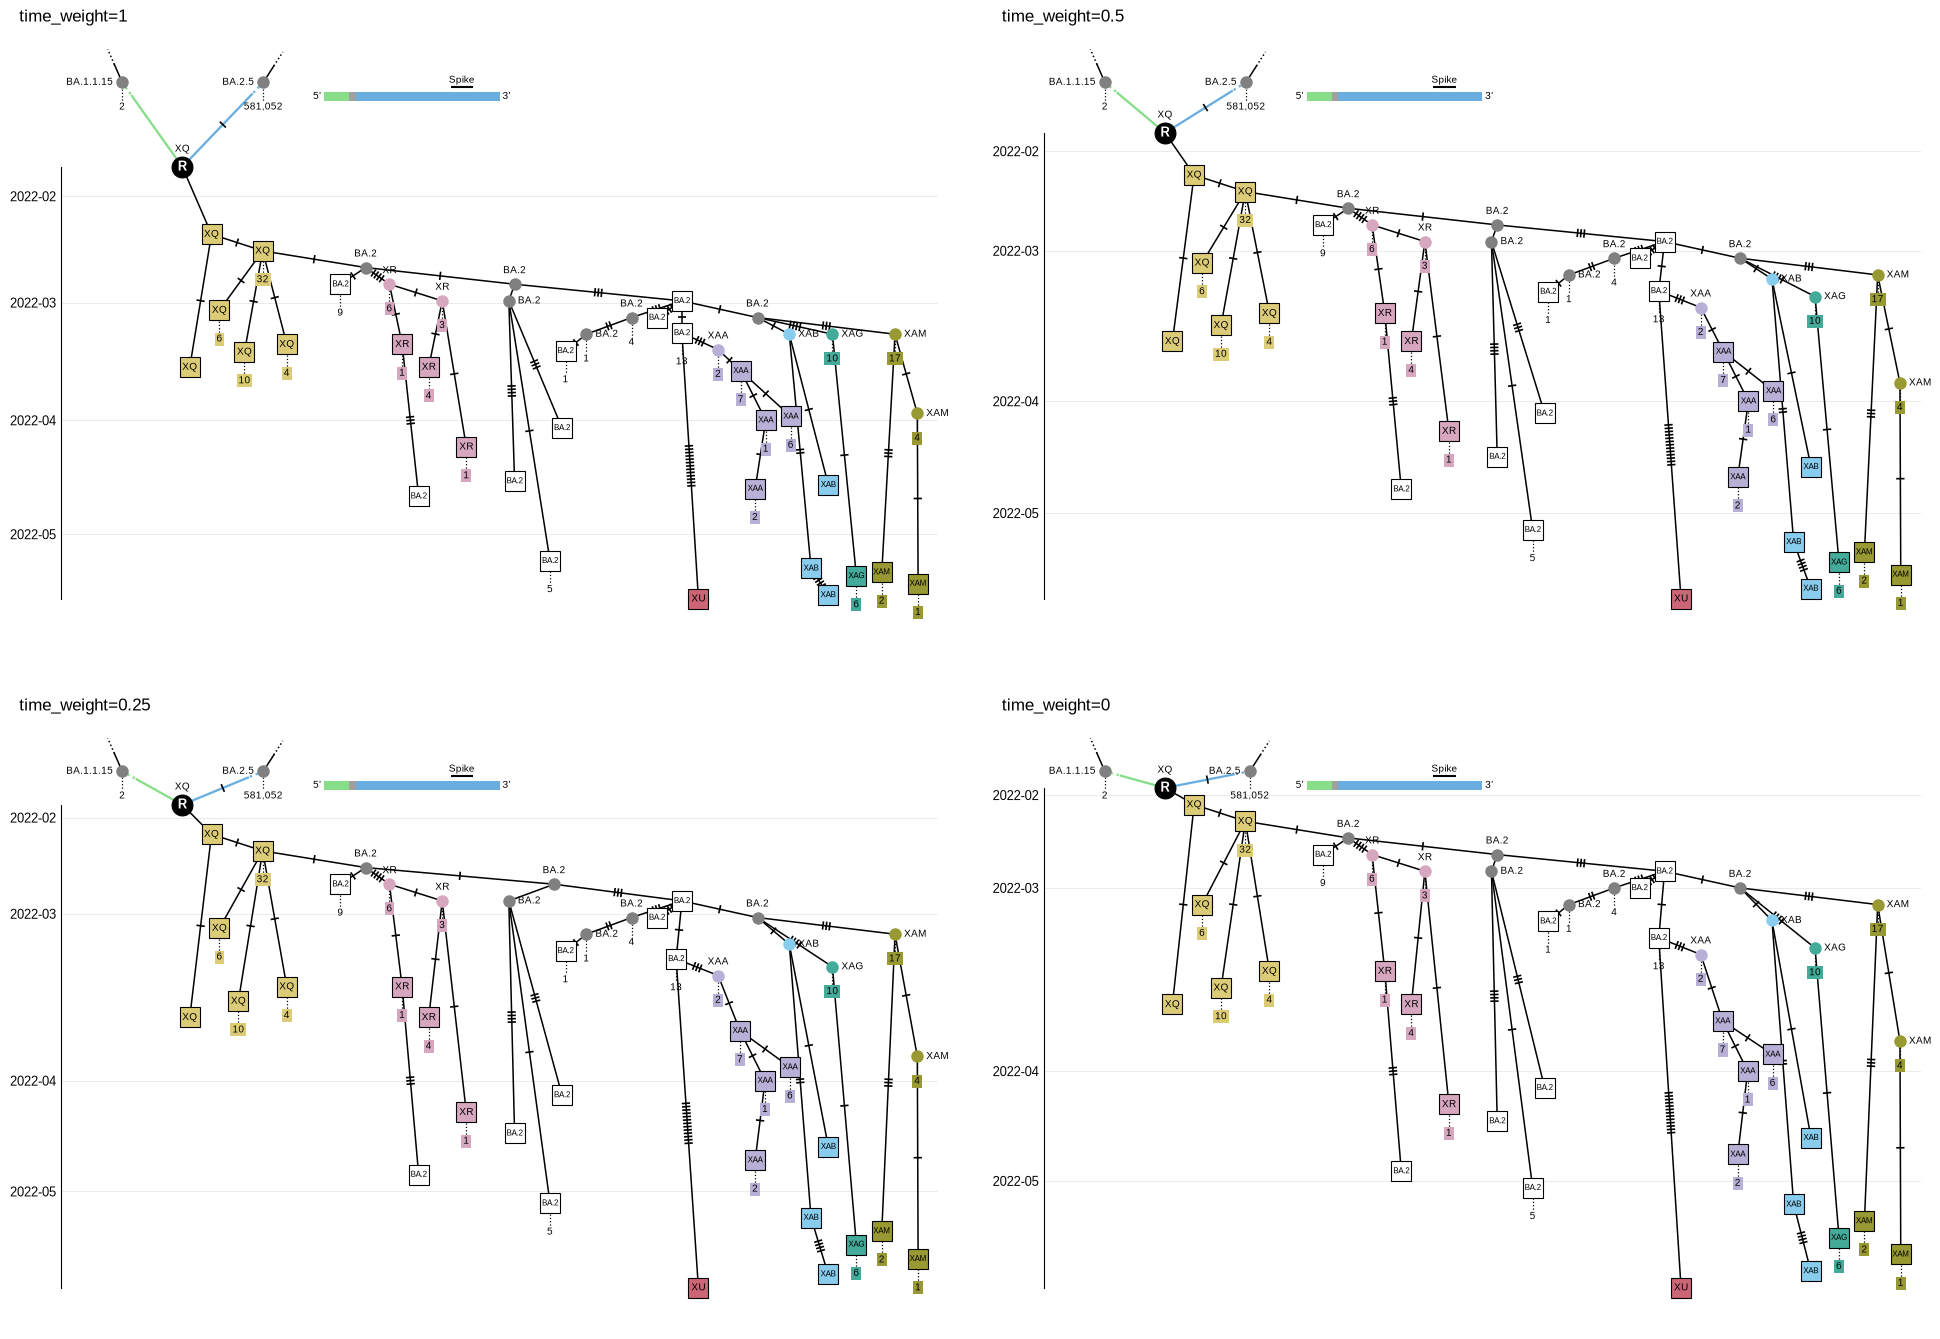

In [6]:
# Compare time scales on the most crowded panel
fig, axes = plt.subplots(2, 2, figsize=(20, 14), layout="none")
fig.subplots_adjust(left=0.06, right=0.99, top=0.95, bottom=0.03, wspace=0.12, hspace=0.15)
for ax, weight in zip(axes.flat, [1, 0.5, 0.25, 0]):
    create_subgraph(
        xq_nodes_df, xq_edges_df, datetime(2024, 6, 6), ax,
        letter="",
        title=f"time_weight={weight}",
        recombinants=recombinants,
        genome_bar_bounds=[0.3, 0.9, 0.2, 0.045],
        time_weight=weight,
        spread=True,
        min_drop=12,
    )
plt.show()

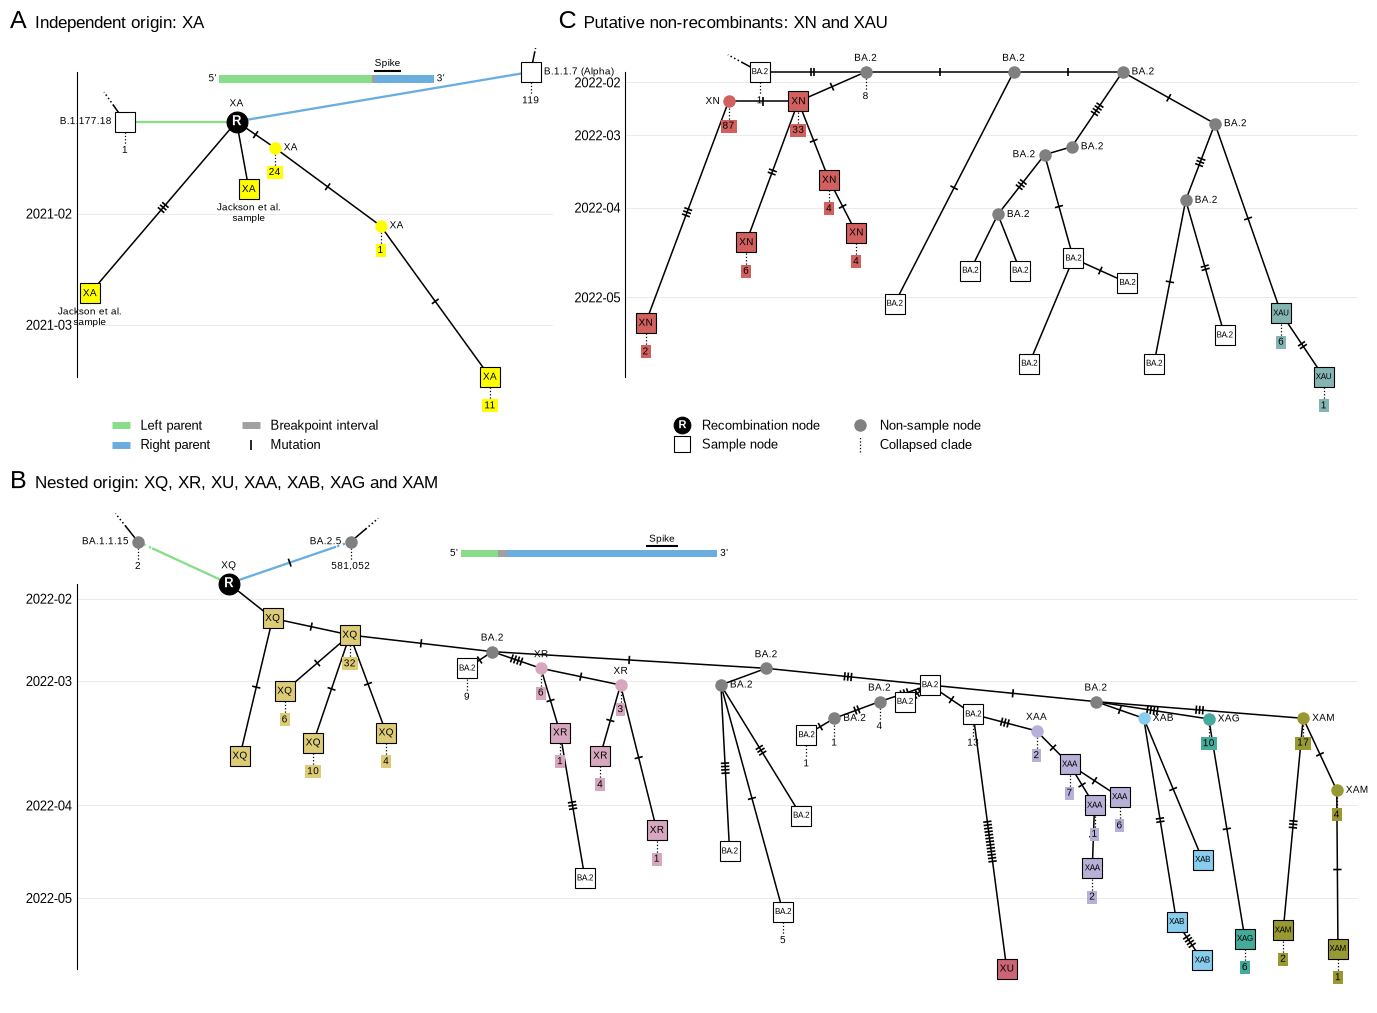

In [7]:
fig = plt.figure(figsize=(14, 10.5), layout="none")
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[2.6, 4],
    height_ratios=[1, 1.4],
    left=0.075, right=0.99,
    top=0.94, bottom=0.03,
    wspace=0.12, hspace=0.25,
)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[1, :])
ax_c = fig.add_subplot(gs[0, 1])

reference_date = datetime(2024, 6, 6)
time_weight = 0.5
create_subgraph(
    xa_nodes_df, xa_edges_df, reference_date, ax_a,
    letter="A",
    title="Independent origin: XA",
    recombinants=recombinants,
    genome_bar_bounds=[0.3, 0.9, 0.45, 0.07],
    legend="genome",
    time_weight=time_weight,
)
create_subgraph(
    xq_nodes_df, xq_edges_df, reference_date, ax_b,
    letter="B",
    title="Nested origin: XQ, XR, XU, XAA, XAB, XAG and XAM",
    recombinants=recombinants,
    genome_bar_bounds=[0.3, 0.9, 0.2, 0.045],
    time_weight=time_weight,
    spread=True,
    min_drop=12,
)
create_subgraph(
    xn_nodes_df, xn_edges_df, reference_date, ax_c,
    letter="C",
    title="Putative non-recombinants: XN and XAU",
    recombinants=recombinants,
    legend="nodes",
    time_weight=time_weight,
)
fig.savefig("../figures/pango_x_subgraphs_auto.pdf")
plt.show()